# E39 — O preço da proteção que protege

Quanto custa, em capital, fechar o buraco que as margens não vêem. As três contas no par real, o
refutador sob pernas independentes, e a família de choque comum do capítulo da margem com o posto
casado. Critérios na docstring do construtor.

In [1]:
import sys
sys.path.insert(0, "lib")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as st

from frevolab import dados, graficos, mudanca, protecao

SEMENTE = 106          # <- brinque com:
JANELA = 252
CAUDA = 0.05
PESOS = (0.5, 0.5)
NIVEL = 0.05
BLOCO = 60
REPETICOES = 200
P_SWEEP = (0.0, 0.02, 0.05, 0.10, 0.20)
NOMES_P = {0.0: "controle", 0.02: "dois", 0.05: "cinco", 0.10: "dez", 0.20: "vinte"}
F_CHOQUE = 3.0
PILOTO = 20000

preco_sp = dados.carregar_serie("sp500.csv")
preco_ib = dados.carregar_serie("ibov.csv")
retornos_sp = preco_sp.pct_change().dropna()
retornos_ib = preco_ib.pct_change().dropna()
print("sp %d | ibov %d dias" % (retornos_sp.size, retornos_ib.size))

sp 6718 | ibov 6620 dias


In [2]:
# A carteira declarada e as contas no par real.
comuns = retornos_sp.index.intersection(retornos_ib.index)
rho_posto = float(st.spearmanr(retornos_sp.loc[comuns], retornos_ib.loc[comuns]).statistic)
SIGMA_MED = 0.5 * (float(retornos_sp.loc[comuns].std()) + float(retornos_ib.loc[comuns].std()))
perdas = protecao.perdas_conjuntas(retornos_sp, retornos_ib, janela=JANELA, cauda=CAUDA, pesos=PESOS)
capital_margem = protecao.capital_marginal(retornos_sp, retornos_ib, janela=JANELA, cauda=CAUDA, pesos=PESOS)
capital_junto = protecao.capital_conjunto(perdas, nivel=NIVEL)
print("posto %.4f | sigma medio %.4f | eventos %d" % (rho_posto, SIGMA_MED, len(perdas)))
print("capital marginal %.4f | conjunto %.4f | razao %.3f" % (capital_margem, capital_junto, capital_junto / capital_margem))
print("descoberto da margem %.3f | do conjunto %.3f" % (
    protecao.descoberto(capital_margem, perdas), protecao.descoberto(capital_junto, perdas)))

posto 0.5036 | sigma medio 0.0145 | eventos 115
capital marginal 0.0202 | conjunto 0.0788 | razao 3.901
descoberto da margem 0.449 | do conjunto 0.036


In [3]:
# O intervalo das contas, por reamostragem em blocos do dia.
int_real = protecao.intervalo(retornos_sp, retornos_ib, janela=JANELA, cauda=CAUDA, pesos=PESOS,
                              nivel=NIVEL, bloco=BLOCO, repeticoes=REPETICOES, semente=SEMENTE + 300)
print("capital conjunto [%.4f; %.4f]" % int_real["capital"])
print("descoberto da margem [%.3f; %.3f]" % int_real["descoberto_marginal"])

capital conjunto [0.0466; 0.1002]
descoberto da margem [0.313; 0.506]


In [4]:
# O refutador: pernas independentes com as margens do par real.
rng_ref = np.random.default_rng(SEMENTE + 100)
serie_ia = pd.Series(float(retornos_sp.loc[comuns].std()) * rng_ref.normal(0.0, 1.0, comuns.size), index=comuns)
serie_ib = pd.Series(float(retornos_ib.loc[comuns].std()) * rng_ref.normal(0.0, 1.0, comuns.size), index=comuns)
perdas_ind = protecao.perdas_conjuntas(serie_ia, serie_ib, janela=JANELA, cauda=CAUDA, pesos=PESOS)
margem_ind = protecao.capital_marginal(serie_ia, serie_ib, janela=JANELA, cauda=CAUDA, pesos=PESOS)
junto_ind = protecao.capital_conjunto(perdas_ind, nivel=NIVEL)
int_ind = protecao.intervalo(serie_ia, serie_ib, janela=JANELA, cauda=CAUDA, pesos=PESOS,
                             nivel=NIVEL, bloco=BLOCO, repeticoes=REPETICOES, semente=SEMENTE + 400)
print("indep | eventos %d | marginal %.4f | conjunto %.4f | razao %.3f" % (
    len(perdas_ind), margem_ind, junto_ind, junto_ind / margem_ind))
print("indep | descoberto da margem %.3f | capital conjunto [%.4f; %.4f]" % (
    protecao.descoberto(margem_ind, perdas_ind), *int_ind["capital"]))

indep | eventos 18 | marginal 0.0238 | conjunto 0.0410 | razao 1.724
indep | descoberto da margem 0.243 | capital conjunto [0.0337; 0.0413]


In [5]:
# A familia de choque comum, com a correlacao TOTAL do par declarada --- a convencao da propria
# familia do capitulo da margem: o rho de entrada e o total, e o corpo e resolvido por dentro. O
# posto realizado de cada mundo e impresso: ele cai quando o choque cresce, e e a propria licao do
# capitulo da margem (mesma correlacao total, estrutura diferente).
rho_total = float(np.corrcoef(retornos_sp.loc[comuns], retornos_ib.loc[comuns])[0, 1])
familia = {}
for p in P_SWEEP:
    xa, xb = mudanca.par_de_cauda(comuns.size, np.random.default_rng(SEMENTE + 200 + int(p * 1000)),
                                  SIGMA_MED, rho_total, p, F_CHOQUE)
    posto_p = float(st.spearmanr(xa, xb).statistic)
    sa = pd.Series(xa, index=comuns)
    sb = pd.Series(xb, index=comuns)
    perdas_p = protecao.perdas_conjuntas(sa, sb, janela=JANELA, cauda=CAUDA, pesos=PESOS)
    margem_p = protecao.capital_marginal(sa, sb, janela=JANELA, cauda=CAUDA, pesos=PESOS)
    junto_p = protecao.capital_conjunto(perdas_p, nivel=NIVEL)
    familia[p] = {"eventos": int(len(perdas_p)), "capital": float(junto_p),
                  "razao": float(junto_p / margem_p),
                  "descoberto": float(protecao.descoberto(margem_p, perdas_p))}
    print("p %.2f | posto realizado %.3f | eventos %3d | razao %.3f | descoberto %.3f" % (
        p, posto_p, len(perdas_p), familia[p]["razao"], familia[p]["descoberto"]))

p 0.00 | posto realizado 0.565 | eventos  90 | razao 1.562 | descoberto 0.206
p 0.02 | posto realizado 0.529 | eventos 106 | razao 2.629 | descoberto 0.342
p 0.05 | posto realizado 0.449 | eventos 106 | razao 3.442 | descoberto 0.472
p 0.10 | posto realizado 0.318 | eventos 165 | razao 3.539 | descoberto 0.474
p 0.20 | posto realizado 0.176 | eventos 258 | razao 2.800 | descoberto 0.417


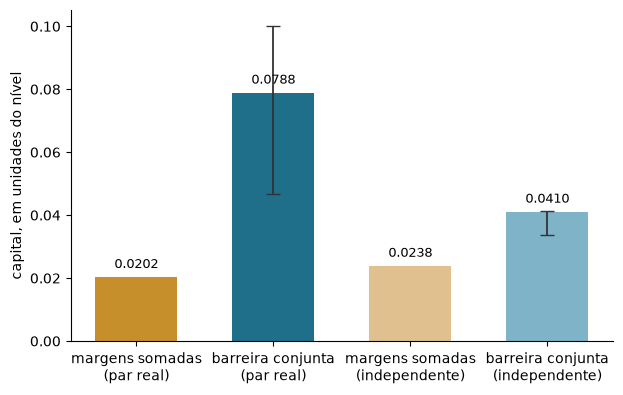

In [6]:
# Figura 1: as contas, no par real e no refutador, com intervalos.
rotulos = ["margens somadas\n(par real)", "barreira conjunta\n(par real)",
           "margens somadas\n(independente)", "barreira conjunta\n(independente)"]
valores = [capital_margem, capital_junto, margem_ind, junto_ind]
cores = ["#c78f2c", "#1f6f8b", "#e0c08f", "#7fb3c8"]
fig, ax = plt.subplots(figsize=(7.0, 4.3))
ax.bar(rotulos, valores, color=cores, width=0.6)
ax.errorbar([1, 3], [capital_junto, junto_ind],
            yerr=[[capital_junto - int_real["capital"][0], junto_ind - int_ind["capital"][0]],
                  [int_real["capital"][1] - capital_junto, int_ind["capital"][1] - junto_ind]],
            fmt="none", ecolor="#333333", capsize=5, lw=1.3)
for i, v in enumerate(valores):
    ax.text(i, v + 0.003, "%.4f" % v, ha="center", fontsize=9)
ax.set_ylabel("capital, em unidades do nível")
ax.spines[["top", "right"]].set_visible(False)
graficos.salvar(fig, "E39_preco", 1)
plt.show()

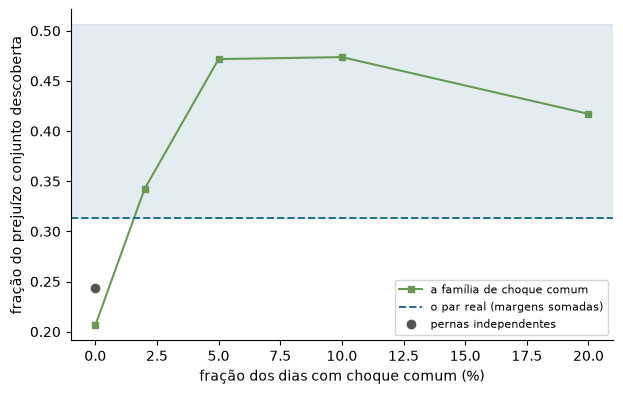

In [7]:
# Figura 2: o descoberto contra a fração de choque, com o par real e o refutador.
xs = np.array([p for p in P_SWEEP])
ys = np.array([familia[p]["descoberto"] for p in P_SWEEP])
fig, ax = plt.subplots(figsize=(7.0, 4.3))
ax.plot(xs * 100, ys, "s-", color="#6a9955", lw=1.5, ms=5, label="a família de choque comum")
ax.axhline(int_real["descoberto_marginal"][0], color="#1f6f8b", ls="--", lw=1.4,
           label="o par real (margens somadas)")
ax.axhspan(int_real["descoberto_marginal"][0], int_real["descoberto_marginal"][1],
           color="#1f6f8b", alpha=0.12)
ax.plot([0.0], [protecao.descoberto(margem_ind, perdas_ind)], "o", color="#555555", ms=6,
        label="pernas independentes")
ax.set_xlabel("fração dos dias com choque comum (%)")
ax.set_ylabel("fração do prejuízo conjunto descoberta")
ax.legend(fontsize=8, loc="best")
ax.spines[["top", "right"]].set_visible(False)
graficos.salvar(fig, "E39_preco", 2)
plt.show()

In [8]:
# Leitura visual das figuras (declaratória, contra o PNG):
# 1) quatro barras com valores anotados: 0,0202 e 0,0788 no par real, 0,0238 e 0,0410 nas
#    independentes; os bigodes de intervalo nas duas barras conjuntas (a do par real é bem mais
#    comprida); a barra mais alta é a conjunta do par real;
# 2) a curva da família sobe de 0,206 no controle a ~0,47 no dez por cento e achata no vinte; a
#    linha tracejada do par real cruza a curva no alto (banda clara em volta); o ponto escuro das
#    independentes está em x zero, logo acima do início da curva.

In [9]:
# O que sai do laboratório e o que o livro cita.
resultado = {"preco_posto": round(rho_posto, 4),
             "preco_rho_total": round(rho_total, 4),
             "preco_sigma_medio": round(SIGMA_MED, 4),
             "preco_eventos": int(len(perdas)),
             "preco_capital_marginal": round(capital_margem, 4),
             "preco_capital_conjunto": round(capital_junto, 4),
             "preco_capital_conjunto_min": round(int_real["capital"][0], 4),
             "preco_capital_conjunto_max": round(int_real["capital"][1], 4),
             "preco_razao": round(capital_junto / capital_margem, 3),
             "preco_descoberto_marginal": round(protecao.descoberto(capital_margem, perdas), 3),
             "preco_descoberto_marginal_min": round(int_real["descoberto_marginal"][0], 3),
             "preco_descoberto_marginal_max": round(int_real["descoberto_marginal"][1], 3),
             "preco_descoberto_conjunto": round(protecao.descoberto(capital_junto, perdas), 3),
             "preco_independente_eventos": int(len(perdas_ind)),
             "preco_independente_capital_marginal": round(margem_ind, 4),
             "preco_independente_capital_conjunto": round(junto_ind, 4),
             "preco_independente_capital_conjunto_min": round(int_ind["capital"][0], 4),
             "preco_independente_capital_conjunto_max": round(int_ind["capital"][1], 4),
             "preco_independente_razao": round(junto_ind / margem_ind, 3),
             "preco_independente_descoberto": round(protecao.descoberto(margem_ind, perdas_ind), 3)}
for p in P_SWEEP:
    resultado["preco_choque_%s_eventos" % NOMES_P[p]] = familia[p]["eventos"]
    resultado["preco_choque_%s_capital" % NOMES_P[p]] = round(familia[p]["capital"], 4)
    resultado["preco_choque_%s_razao" % NOMES_P[p]] = round(familia[p]["razao"], 3)
    resultado["preco_choque_%s_descoberto" % NOMES_P[p]] = round(familia[p]["descoberto"], 3)

CITADAS_NO_LIVRO = tuple(sorted(resultado))
resultado = {k: v for k, v in resultado.items() if k in CITADAS_NO_LIVRO}
import json
from pathlib import Path
caminho = Path("lab/resultados/E39_preco_da_protecao.json")
caminho.write_text(json.dumps(resultado, indent=1, ensure_ascii=False, sort_keys=True), encoding="utf-8")
print(json.dumps(resultado, ensure_ascii=False, indent=1, sort_keys=True))

{
 "preco_capital_conjunto": 0.0788,
 "preco_capital_conjunto_max": 0.1002,
 "preco_capital_conjunto_min": 0.0466,
 "preco_capital_marginal": 0.0202,
 "preco_choque_cinco_capital": 0.0861,
 "preco_choque_cinco_descoberto": 0.472,
 "preco_choque_cinco_eventos": 106,
 "preco_choque_cinco_razao": 3.442,
 "preco_choque_controle_capital": 0.037,
 "preco_choque_controle_descoberto": 0.206,
 "preco_choque_controle_eventos": 90,
 "preco_choque_controle_razao": 1.562,
 "preco_choque_dez_capital": 0.098,
 "preco_choque_dez_descoberto": 0.474,
 "preco_choque_dez_eventos": 165,
 "preco_choque_dez_razao": 3.539,
 "preco_choque_dois_capital": 0.0657,
 "preco_choque_dois_descoberto": 0.342,
 "preco_choque_dois_eventos": 106,
 "preco_choque_dois_razao": 2.629,
 "preco_choque_vinte_capital": 0.0972,
 "preco_choque_vinte_descoberto": 0.417,
 "preco_choque_vinte_eventos": 258,
 "preco_choque_vinte_razao": 2.8,
 "preco_descoberto_conjunto": 0.036,
 "preco_descoberto_marginal": 0.449,
 "preco_descoberto_ma